In [1]:
import random
import pandas as pd
import numpy as np
import pwlf

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 20
df_name = "AAPL_1hour"

df = pd.read_csv(f'../datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.9 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [2]:
def build_min_vectors_by_slopes(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            x = np.arange(N + 1)
            y = df.iloc[i-N:i + 1]['open'].values
            model = pwlf.PiecewiseLinFit(x, y)
            _ = model.fit(4)
            vectors.append(model.slopes)
    return np.array(vectors)

def build_max_vectors_by_slopes(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_max'] or take_all:
            x = np.arange(N + 1)
            y = df.iloc[i-N:i + 1]['open'].values
            model = pwlf.PiecewiseLinFit(x, y)
            _ = model.fit(4)
            vectors.append(model.slopes)
    return np.array(vectors)

X_train_min = build_min_vectors_by_slopes(df_train, N)
X_train_max = build_max_vectors_by_slopes(df_train, N)
print(X_train_min.shape, X_train_max.shape)

(102, 4) (92, 4)


***Минимумы***

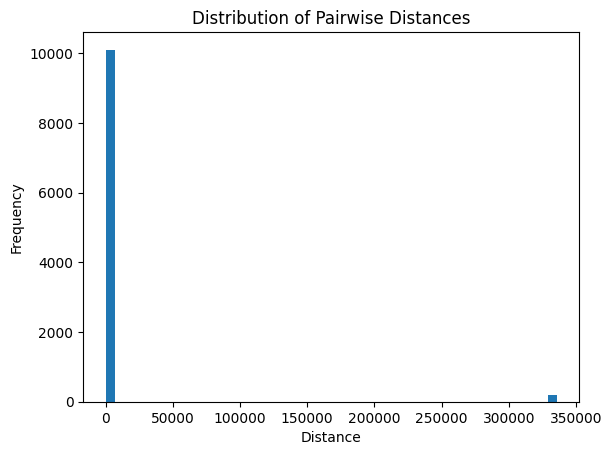

In [3]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_min)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

Как можно заметить, расстояния нерепрезентативны. Это происходит из-за того, что наклоны прямых могут иметь очень разные масштаб, а также могут быть выбросы.

Допустим, для двух экстремумов:
$V1 = [8500, -4300, 1.0]$

$V2 = [8600, -4400, 1.5]$

Евклидово расстояние:
$d = sqrt((8600-8500)^2 + (-4400-(-4300))^2 + (1.5-1.0)^2)
  = sqrt(10000 + 10000 + 0.25)
  ≈ 141$
  
Третий признак (slope=1.0) вообще не влияет на расстояние, потому что первые два признака на порядки больше. Фактически кластеризация идёт только по двум числам, а третье игнорируется.

Плюс, pwlf иногда строит прямые с очень большими по модулю наклонами и очень близкими концами, хотя можно отдалить концы, и тогда наклоны станут адекватнее (это в нашем случае и есть выбросы)

In [4]:
lower = np.percentile(X_train_min, 3, axis=0)
upper = np.percentile(X_train_min, 97, axis=0)
print("Lower percentiles (3%):", lower)
print("Upper percentiles (97%):", upper)

mask = np.all((X_train_min >= lower) & (X_train_min <= upper), axis=1)
X_train_clean = X_train_min[mask]

print(f"Осталось {mask.sum()} из {len(mask)} точек")

Lower percentiles (3%): [-1.26248298 -6.80940825 -8.16034116 -8.66599811]
Upper percentiles (97%): [ 2.12111281  7.43125165  5.595593   -0.10786682]
Осталось 75 из 102 точек


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

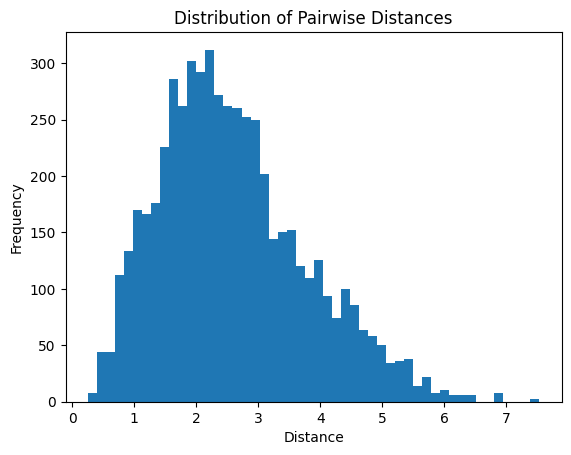

In [6]:
distances = euclidean_distances(X_train_scaled)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [7]:
print("Max values:")
print(np.max(X_train_scaled, axis=0))
print("Min values:")
print(np.min(X_train_scaled, axis=0))
print("Median values:")
print(np.median(X_train_scaled, axis=0))

Max values:
[2.87900821 2.98083393 3.34510046 0.95788856]
Min values:
[-2.67909544 -2.89632408 -2.99618876 -3.96203925]
Median values:
[-0.02359273  0.01744543 -0.22969596  0.29902701]


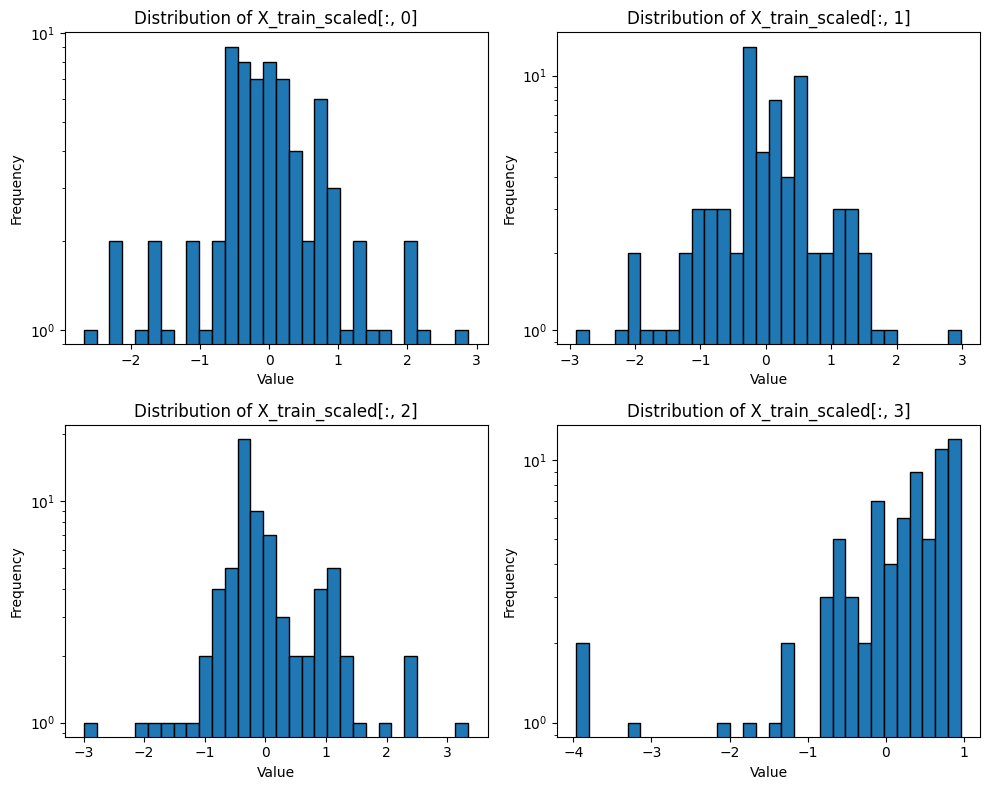

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].hist(X_train_scaled[:, i], bins=30, edgecolor='black')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of X_train_scaled[:, {i}]')
    axes[row, col].set_yscale('log')

plt.tight_layout()
plt.show()

**DBSCAN**

In [28]:
from sklearn.cluster import DBSCAN

EPS = 1.5
clustering = DBSCAN(eps=EPS, min_samples=5).fit(X_train_scaled)
clustering.labels_

array([-1,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,
        0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1, -1,  0,  0,  0, -1,  0,  0,  0, -1,  0, -1,  0, -1,
        0,  0])

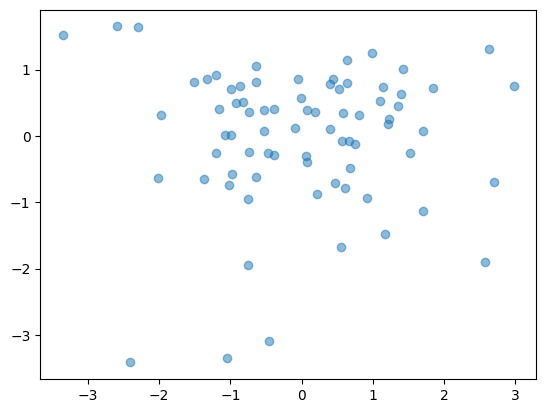

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5)
plt.show()

In [11]:
X_test = build_min_vectors_by_slopes(df_test, N, take_all=True)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_test_scaled.shape

(980, 4)

In [31]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering.labels_[clustering.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_scaled, X_test_scaled[i - N], EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.4143, Recall: 0.6667, Precision: 0.0069, F1 Score: 0.0137, ROC_AUC: 0.5397


precition != -1

Accuracy: 0.5857, Recall: 0.3333, Precision: 0.0050, F1 Score: 0.0098, ROC_AUC: 0.4603

prediction == -1

Accuracy: 0.4143, Recall: 0.6667, Precision: 0.0069, F1 Score: 0.0137, ROC_AUC: 0.5397

**KMeans**

In [33]:
from sklearn.cluster import KMeans

clustering = KMeans(n_clusters=2).fit(X_train_scaled)
clustering.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0], dtype=int32)

In [34]:
def predict_kmeans(v, threshold=None):
    label = clustering.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test_scaled[i - N], threshold=EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.8367, Recall: 0.1667, Precision: 0.0064, F1 Score: 0.0123, ROC_AUC: 0.5038


***Максимумы***

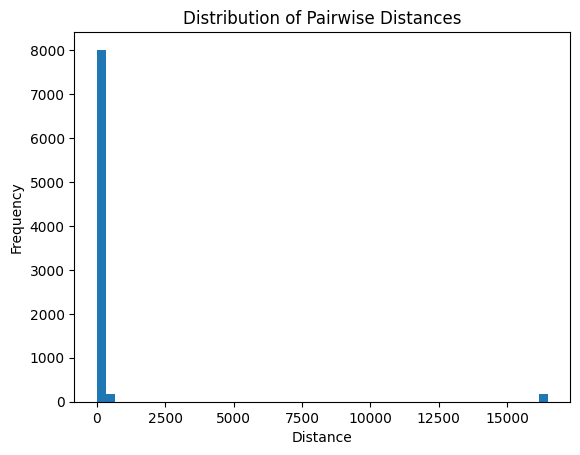

In [16]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_max)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [35]:
lower = np.percentile(X_train_max, 3, axis=0)
upper = np.percentile(X_train_max, 97, axis=0)
print("Lower percentiles (3%):", lower)
print("Upper percentiles (97%):", upper)

mask = np.all((X_train_max >= lower) & (X_train_max <= upper), axis=1)
X_train_clean = X_train_max[mask]

print(f"Осталось {mask.sum()} из {len(mask)} точек")

Lower percentiles (3%): [-1.8456971  -5.44750795 -4.45660013  0.11573573]
Upper percentiles (97%): [ 1.66380437 16.2145251   4.15984359 15.5781155 ]
Осталось 70 из 92 точек


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

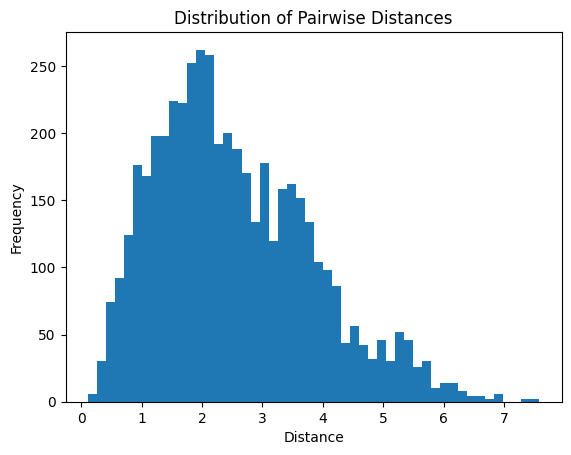

In [19]:
distances = euclidean_distances(X_train_scaled)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [20]:
print("Max values:")
print(np.max(X_train_scaled, axis=0))
print("Min values:")
print(np.min(X_train_scaled, axis=0))
print("Median values:")
print(np.median(X_train_scaled, axis=0))

Max values:
[3.38755041 4.04366229 3.10266384 4.57052315]
Min values:
[-2.84477263 -2.04241536 -3.92331335 -0.77268932]
Median values:
[ 0.14101761 -0.10140092  0.04122067 -0.39925155]


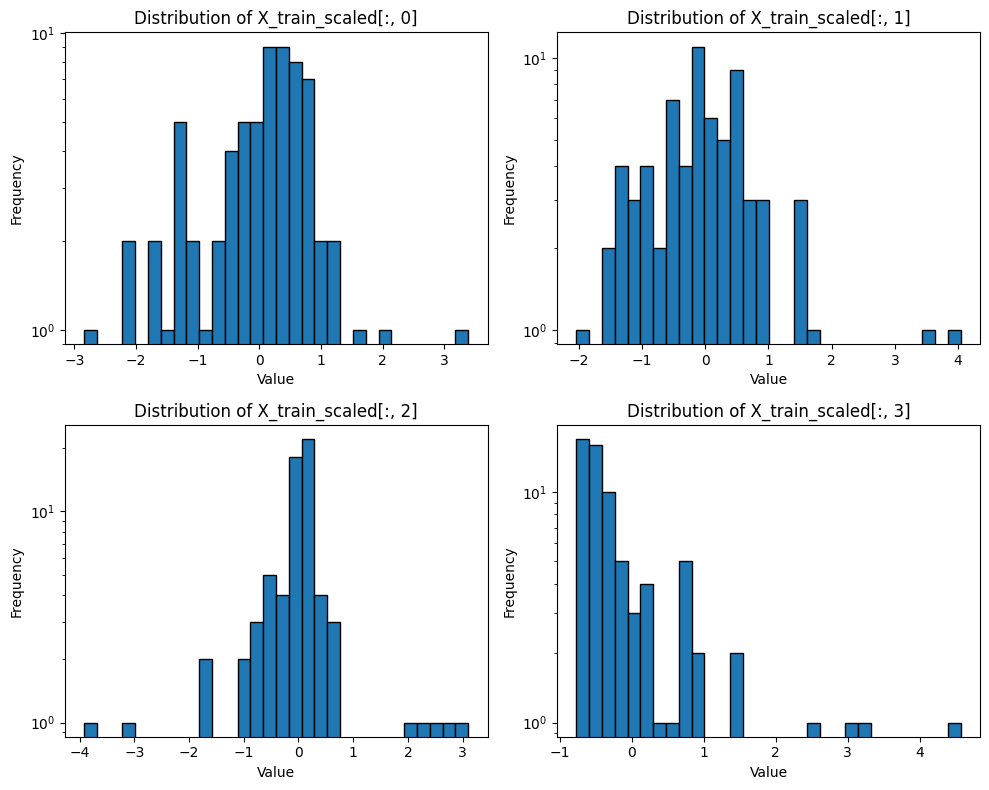

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].hist(X_train_scaled[:, i], bins=30, edgecolor='black')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of X_train_scaled[:, {i}]')
    axes[row, col].set_yscale('log')

plt.tight_layout()
plt.show()

**DBSCAN**

In [37]:
from sklearn.cluster import DBSCAN

EPS = 1.5
clustering = DBSCAN(eps=EPS, min_samples=5).fit(X_train_scaled)
clustering.labels_

array([-1,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,  0,  0,  0,  0,
       -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0, -1,  0,
        0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1, -1,  0,  0,  0, -1,  0,  0,  0, -1,  0, -1,  0, -1,
        0,  0])

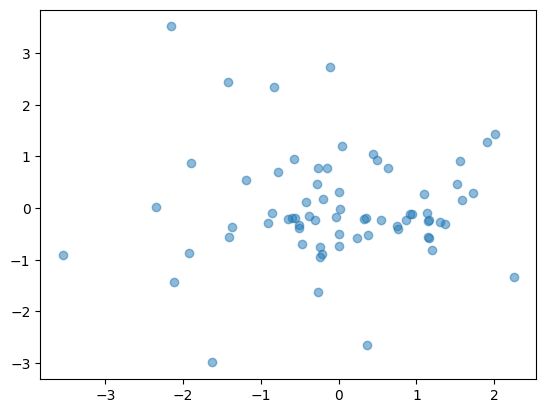

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5)
plt.show()

In [40]:
def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering.labels_[clustering.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_scaled, X_test_scaled[i - N], EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.4153, Recall: 1.0000, Precision: 0.0052, F1 Score: 0.0104, ROC_AUC: 0.7068


prediction != -1

Accuracy: 0.5847, Recall: 0.0000, Precision: 0.0000, F1 Score: 0.0000, ROC_AUC: 0.2932

prediction == -1

Accuracy: 0.4153, Recall: 1.0000, Precision: 0.0052, F1 Score: 0.0104, ROC_AUC: 0.7068

**KMeans**

In [41]:
from sklearn.cluster import KMeans

clustering = KMeans(n_clusters=2).fit(X_train_scaled)
clustering.labels_

array([0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0], dtype=int32)

In [43]:
def predict_kmeans(v, threshold=None):
    label = clustering.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test_scaled[i - N], threshold=EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.1827, Recall: 1.0000, Precision: 0.0037, F1 Score: 0.0074, ROC_AUC: 0.5901
